# Kaggle Dataset Link - 'https://www.kaggle.com/datasets/andrewmvd/pothole-detection'

# Install Dependencies

In [1]:
!pip install -q supervision ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.9 MB/s eta 0:00:00


# Import Modules

In [2]:
import supervision as sv
from ultralytics import YOLO 

import pandas as pd 
import matplotlib.pyplot as plt 

import os 
import shutil 
import random 
import cv2

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Load The Dataset

In [3]:
IMG_DIR = '/kaggle/input/datasets/andrewmvd/pothole-detection/images'
ANN_DIR = '/kaggle/input/datasets/andrewmvd/pothole-detection/annotations'
FINAL_DIR = '/kaggle/working/PlotholeDataset'

# Remove old directory 

if os.path.exists(FINAL_DIR):
    shutil.rmtree(FINAL_DIR)

os.makedirs(FINAL_DIR, exist_ok= True)

In [5]:
# Load Pascal VOC XML  

dataset = sv.DetectionDataset.from_pascal_voc(
    images_directory_path = IMG_DIR,
    annotations_directory_path= ANN_DIR
)

print(f'Total Images', len(dataset))

Total Images 665


# Data Preprocessing

In [6]:
# Split Dataset (80/10/10)

train_dataset, remaining_dataset = dataset.split(split_ratio=0.8)
valid_dataset, test_dataset = remaining_dataset.split(split_ratio=0.5)

print('Train', len(train_dataset))
print('Valid', len(valid_dataset))
print('Test', len(test_dataset))

Train 532
Valid 66
Test 67


In [7]:
# Export To Yolo Format 

train_dataset.as_yolo(
    images_directory_path=os.path.join(FINAL_DIR, 'train/images'), 
    annotations_directory_path=os.path.join(FINAL_DIR, 'train/labels')
)

valid_dataset.as_yolo(
    images_directory_path=os.path.join(FINAL_DIR, 'valid/images'), 
    annotations_directory_path=os.path.join(FINAL_DIR, 'valid/labels')
)

test_dataset.as_yolo(
    images_directory_path=os.path.join(FINAL_DIR, 'test/images'), 
    annotations_directory_path=os.path.join(FINAL_DIR, 'test/labels'),
    data_yaml_path=os.path.join(FINAL_DIR, 'data.yaml')
)

print("YOLO export done!")

YOLO export done!


In [8]:
import yaml

# Fix / Overwrite data.yaml File (For YOLOv8)

DATA_YAML_PATH = os.path.join(FINAL_DIR, 'data.yaml')

data = {
    'path': FINAL_DIR,
    'train': 'train/images',
    'val': 'valid/images',
    'test' : 'test/images',
    'nc' : 1,
    'names': ['pothole']
}

with open(DATA_YAML_PATH, 'w') as f:
    yaml.dump(data, f)

print('\n data.yaml created at:', DATA_YAML_PATH)

print(f'\n Final YOLO Dataset Ready AT: {FINAL_DIR}')


 data.yaml created at: /kaggle/working/PlotholeDataset/data.yaml

 Final YOLO Dataset Ready AT: /kaggle/working/PlotholeDataset


In [9]:
import glob

for split in ['train', 'valid', 'test']:
    img_count = len(glob.glob(os.path.join(FINAL_DIR, split, 'images', '*.*')))
    lbl_count = len(glob.glob(os.path.join(FINAL_DIR, split, 'labels', '*.txt')))
    print(f"{split.upper()} -> Images: {img_count} | Labels: {lbl_count}")

TRAIN -> Images: 532 | Labels: 532
VALID -> Images: 66 | Labels: 66
TEST -> Images: 67 | Labels: 67


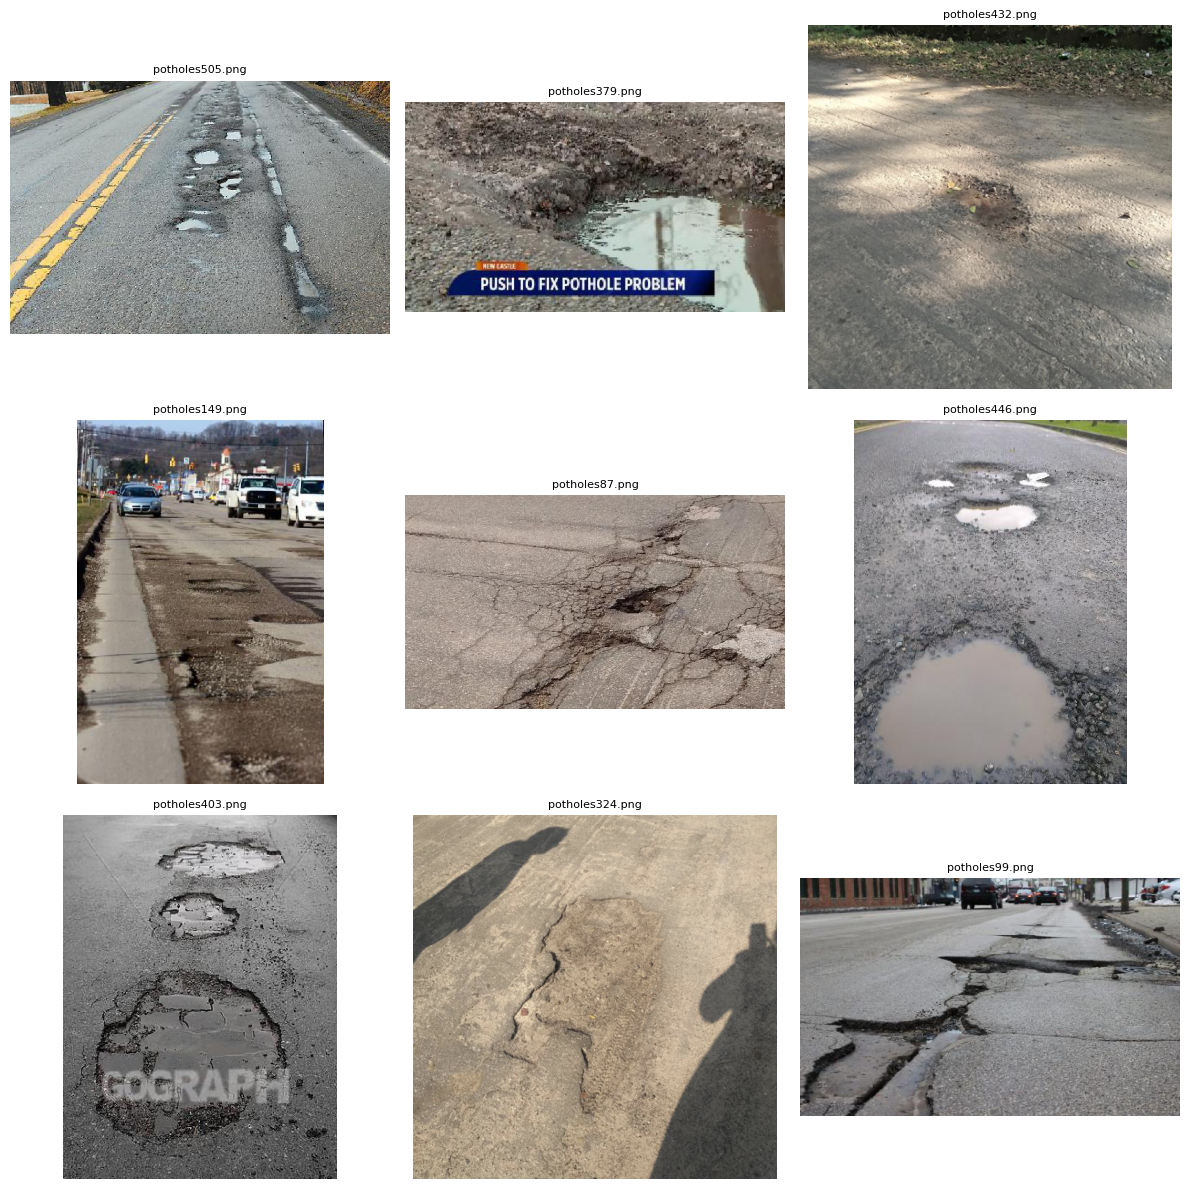

In [10]:
# Visualize Random Test Images 

TRAIN_IMG_DIR = f'{FINAL_DIR}/train/images'

train_images = os.listdir(TRAIN_IMG_DIR)
sample_images = random.sample(train_images, 9)

plt.figure(figsize=(12, 12))

for i, image_name in enumerate(sample_images):
    image_path = os.path.join(TRAIN_IMG_DIR, image_name)

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(image_name, fontsize = 8)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Model Building

In [11]:
# Load The Yolo Model 

model = YOLO('yolov8n.pt')

In [12]:
# Train the YOLO Model 

model.train(
    data = DATA_YAML_PATH,
    epochs = 100, 
    batch = 16,
    imgsz = 640,
    name = 'train',
    cache=True,
    exist_ok = True
)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/PlotholeDataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fb99d53a270>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [13]:
# Check the results 

results_csv = '/kaggle/working/runs/detect/train/results.csv'
df = pd.read_csv(results_csv)

df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,8.62098,1.64692,2.59067,1.52920,0.89187,0.04155,0.23436,0.11439,1.52365,2.97017,1.49651,0.000647,0.000647,0.000647
1,2,14.35540,1.57530,2.01637,1.45778,0.36442,0.21106,0.16436,0.07408,1.63519,2.69256,1.53780,0.001301,0.001301,0.001301
2,3,20.05300,1.58111,1.98611,1.51566,0.05415,0.13568,0.02580,0.01138,1.81218,4.98154,2.19293,0.001941,0.001941,0.001941
3,4,25.79000,1.58016,1.77966,1.46956,0.44468,0.33166,0.27553,0.12179,1.73282,2.39469,1.82795,0.001941,0.001941,0.001941
4,5,31.53420,1.54122,1.73861,1.47466,0.26302,0.31156,0.15022,0.07588,1.54445,2.22243,1.66419,0.001921,0.001921,0.001921


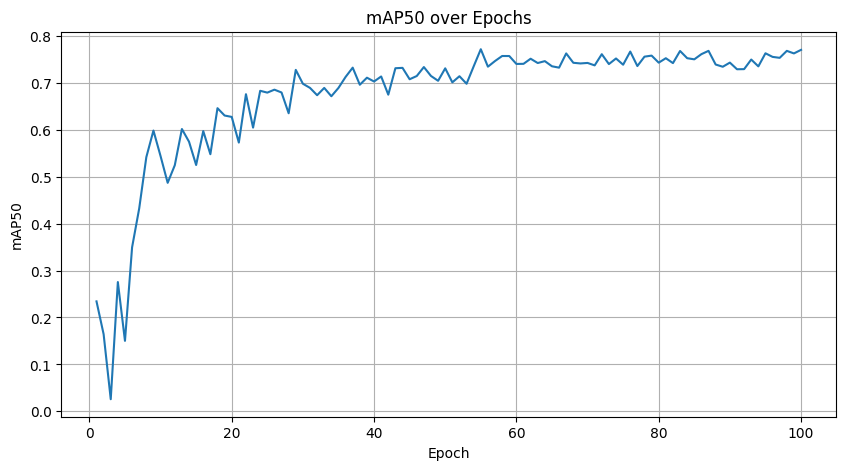

In [14]:
# PLOT TRAINING GRAPH (mAP50 over Epochs)

plt.figure(figsize=(10, 5))
plt.plot(df["epoch"], df["metrics/mAP50(B)"])
plt.title("mAP50 over Epochs")
plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.grid(True)
plt.show()

# Model Evaluation

In [15]:
# Load Best Model

BEST_MODEL_PATH = '/kaggle/working/runs/detect/train/weights/best.pt'
best_model = YOLO(BEST_MODEL_PATH)

# Evaluate On Test Dataset (After Prediction)

best_model.val(
    data = DATA_YAML_PATH,
    split = 'test'
)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4338.5±1347.5 MB/s, size: 640.7 KB)
val: Scanning /kaggle/working/PlotholeDataset/test/labels... 67 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 67/67 475.6it/s 0.1s0.2s
val: New cache created: /kaggle/working/PlotholeDataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.7it/s 1.8s0.5s
                   all         67        204       0.84      0.676      0.754      0.487
Speed: 4.1ms preprocess, 10.8ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fb8ecb878c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

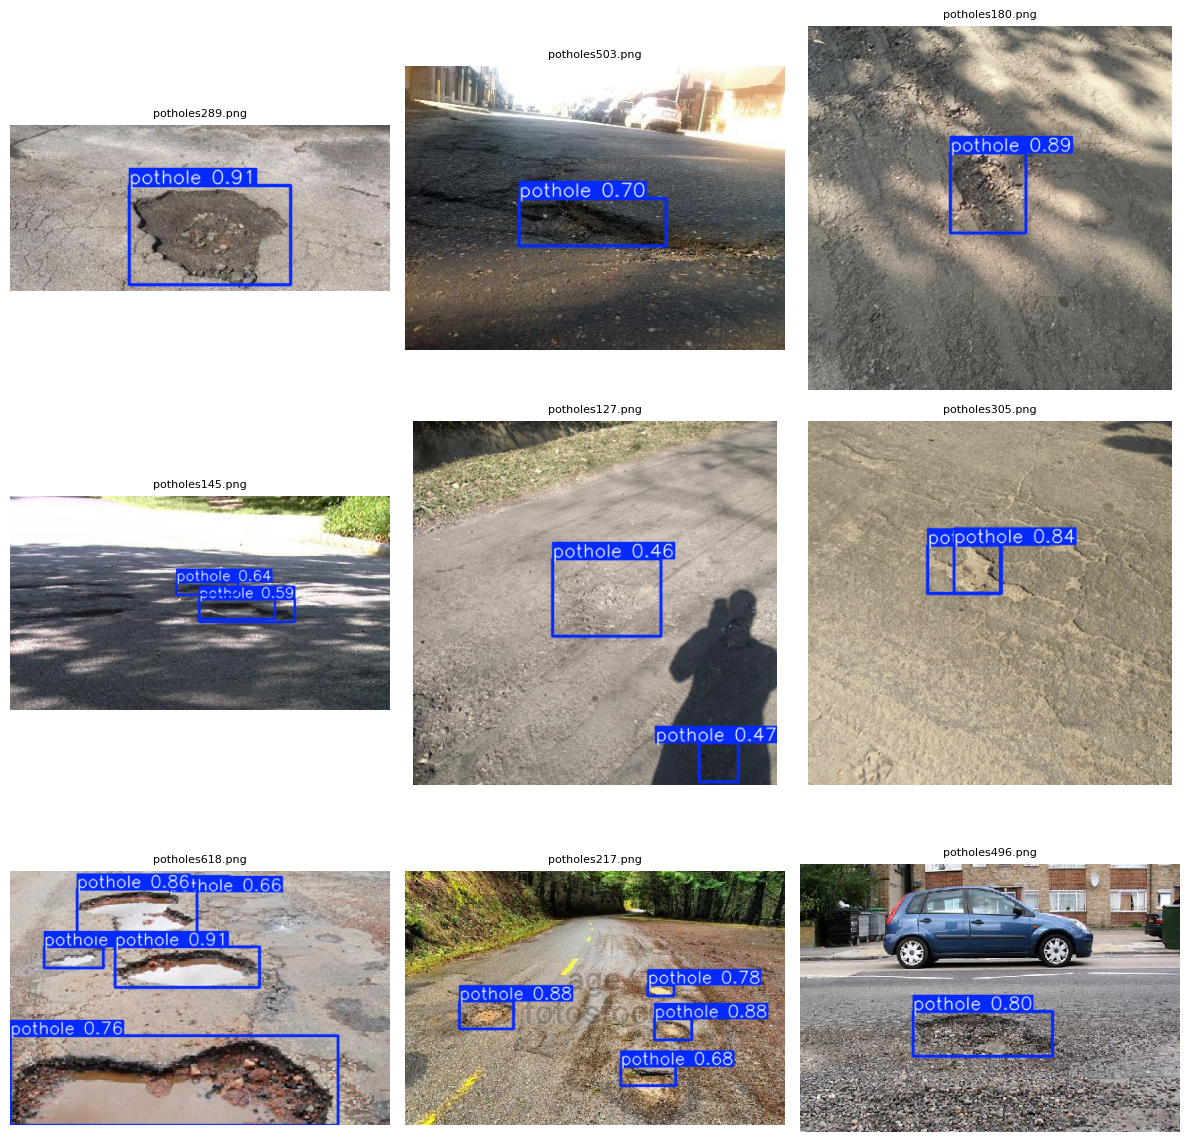

In [17]:
# VISUALIZE RANDOM TEST PREDICTIONS (AFTER TRAINING) - > Plot using yolo's result function 

TEST_IMG_DIR = f'{FINAL_DIR}/test/images'

test_images = os.listdir(TEST_IMG_DIR)

sample_test_images = random.sample(test_images, 9)

plt.figure(figsize=(12, 12))

for i, image_name in enumerate(sample_test_images):
    image_path = os.path.join(TEST_IMG_DIR, image_name)

    results = model.predict(image_path, conf=0.4, imgsz=640, verbose=False)[0]

    annotated_image = results.plot()

    annotated_image = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i+1)
    plt.imshow(annotated_image)
    plt.title(image_name, fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# # Single Image


# # ==============================
# # SINGLE IMAGE PATH
# # ==============================
# image_path = f"{FINAL_DIR}/test/images/plot-hole.png"   # <-- change image name
# image_name = os.path.basename(image_path)

# # ==============================
# # YOLO PREDICTION
# # ==============================
# results = model.predict(image_path, conf=0.4, imgsz=640, verbose=False)[0]

# # ==============================
# # PLOT YOLO RESULT
# # ==============================
# annotated_image = results.plot()

# # Convert BGR to RGB for matplotlib
# annotated_image = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

# # ==============================
# # SHOW IMAGE
# # ==============================
# plt.figure(figsize=(10, 7))
# plt.imshow(annotated_image)
# plt.title(image_name, fontsize=12)
# plt.axis("off")
# plt.show()